# House Price Prediction

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error,mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,BaggingRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler,LabelEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline  import Pipeline

## 2. Load Dataset

In [3]:
data = pd.read_csv("Housing.csv")

In [4]:
data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


## 3. Data Exploration

In [5]:
print("shape:",data.shape)
print("size:",data.size) # The dataset contains 545 rows and 13 columns.

shape: (545, 13)
size: 7085


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
# # checking duplicated values in dataset
data.isnull().mean()*100 # data set don't have any missing values.

price               0.0
area                0.0
bedrooms            0.0
bathrooms           0.0
stories             0.0
mainroad            0.0
guestroom           0.0
basement            0.0
hotwaterheating     0.0
airconditioning     0.0
parking             0.0
prefarea            0.0
furnishingstatus    0.0
dtype: float64

### The target variable is Price.
### The dataset contains both numerical and categorical features.
### No significant missing values were observed.

## 4. Data Cleaning

In [9]:
# checking duplicated values in dataset
data.duplicated().sum() # data set don't have any duplicated values.

0

In [10]:
# checking duplicated values in dataset
data.isnull().sum() # data set don't have any duplicated values.

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## 5. Data Preprocessing

In [11]:
data = pd.get_dummies(data,columns=data.select_dtypes(include=["object","bool"]).columns,drop_first=True).astype('int')

In [12]:
data.sample(3) # Categorical variables were transformed into numerical form using One-Hot Encoding.

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
151,5565000,4400,4,1,2,2,1,0,0,0,1,1,1,0
230,4690000,5400,2,1,2,0,1,0,0,0,0,1,1,0
35,8080940,7000,3,2,4,2,1,0,0,0,1,0,0,0


## 6. EDA

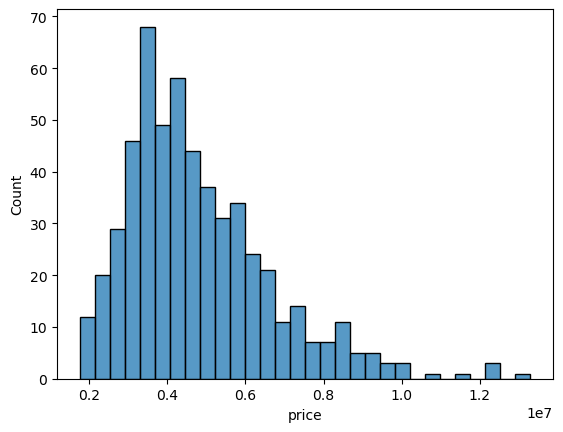

In [13]:
sns.histplot(data["price"], bins=30)
plt.savefig("charts/histogram.png")
plt.show()


#### The histogram shows that house prices are slightly right-skewed. Most properties are concentrated in the lower to middle price range, while only a small number of houses have very high prices. This indicates that expensive houses are less common in the dataset.

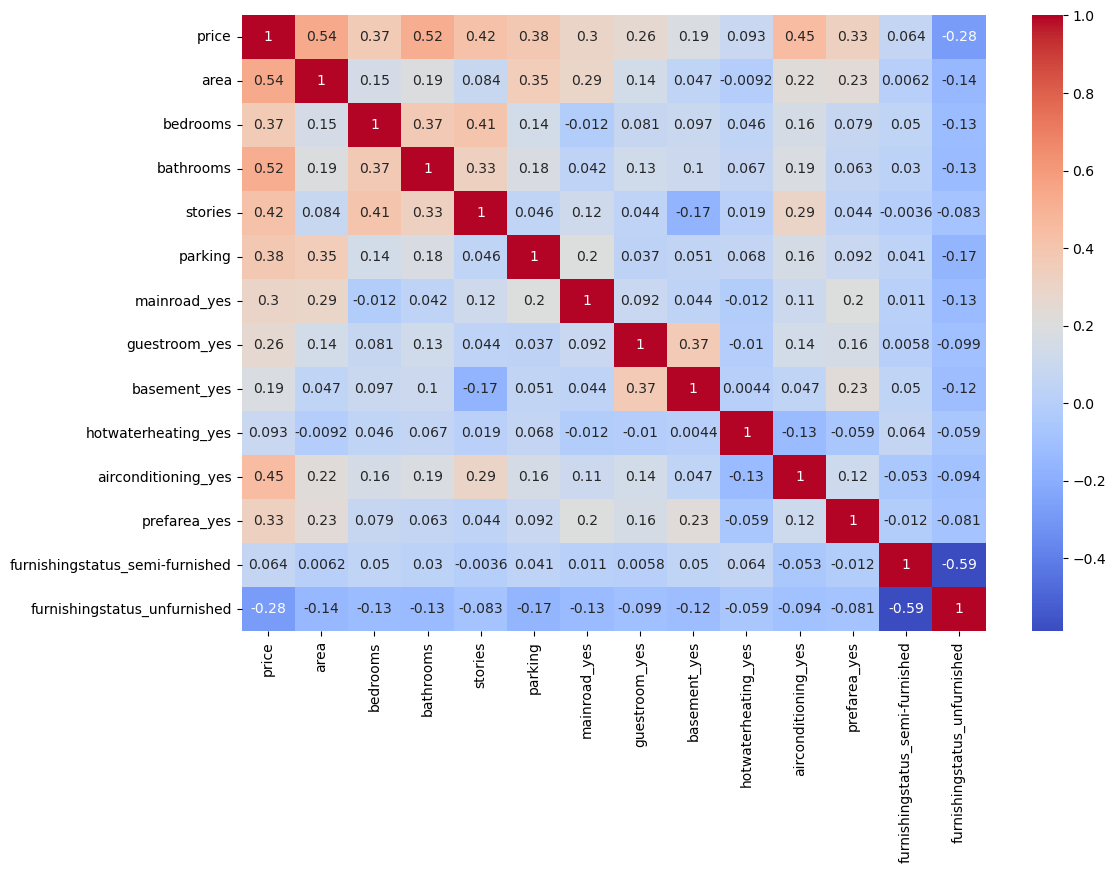

In [14]:
plt.figure(figsize=(12,8))

sns.heatmap(
    data.corr(),
    annot=True,
    
    cmap="coolwarm",
)
plt.savefig("charts/corr heatmap.png")
plt.show()

#### The correlation heatmap shows that area (0.54) and bathrooms (0.52) have the strongest positive relationship with house price. Air conditioning (0.45), stories (0.42), and parking (0.38) also contribute positively to house value. These results suggest that larger houses with more amenities tend to command higher prices in the market.

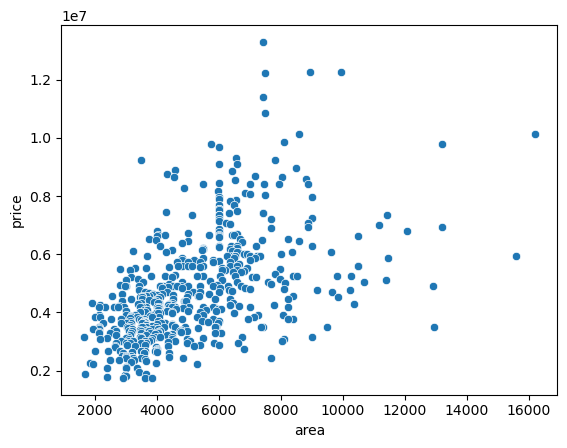

In [15]:
sns.scatterplot(
    x="area",
    y="price",
    data=data
)
plt.savefig("charts/scatter plot.png")
plt.show()

### The scatter plot reveals a positive relationship between area and house price. In general, larger houses tend to have higher prices. However, the points are not perfectly aligned, indicating that other factors such as bathrooms, parking, and air conditioning also influence property value.

### 7.Split Data

In [16]:
x = data.drop("price", axis=1)
y = data[["price"]]
y

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000
...,...
540,1820000
541,1767150
542,1750000
543,1750000


In [17]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

### 8.Train Linear Regression

In [18]:
lr = LinearRegression()

lr.fit(x_train,y_train)

LinearRegression()

In [19]:
lr_pred = lr.predict(x_test)

In [20]:
mae_lr = mean_absolute_error(y_test,lr_pred)

rmse_lr = np.sqrt(mean_squared_error(y_test,lr_pred))

r2_lr = r2_score(y_test,lr_pred)

In [21]:
print(mae_lr)
print(rmse_lr)
print(r2_lr)

970043.403920164
1324506.9600914388
0.6529242642153184


### 9. Train Random Forest

In [22]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [23]:
rf_pred = rf.predict(x_test)

In [24]:
mae_rf = mean_absolute_error(y_test,rf_pred)

rmse_rf = np.sqrt(mean_squared_error(y_test,rf_pred))

r2_rf = r2_score(y_test,rf_pred)

In [25]:
print(mae_rf)
print(rmse_rf)
print(r2_rf)

1021546.0353211008
1400565.9728553821
0.611918531405699


In [26]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[mae_lr,mae_rf],
    "RMSE":[rmse_lr,rmse_rf],
    "R2":[r2_lr,r2_rf]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


#### The Linear Regression model outperformed the Random Forest Regressor on all evaluation metrics. It achieved a lower MAE and RMSE while obtaining a higher R² score. Therefore, Linear Regression was selected as the final model for predicting house prices.

## 10. Feature Importance

In [27]:
importance = pd.DataFrame({
    "Feature":x.columns,
    "Importance":rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226


### 11. Actual vs Predicted Chart

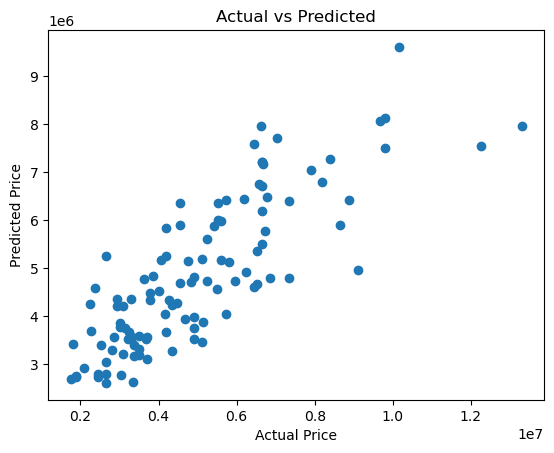

In [28]:
plt.scatter(
    y_test,
    lr_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.savefig("charts/actual_vs_predicted.png")
plt.show()

### 12. Write Insights

#### The analysis revealed that area, bathrooms, air conditioning, stories, and parking are the most influential factors affecting house prices. The correlation heatmap showed strong positive relationships between these features and the target variable. The histogram indicated a slightly right-skewed distribution, meaning that high-priced houses are less common than lower-priced properties. The scatter plot demonstrated a clear positive relationship between house area and price. Among the tested models, Linear Regression performed better than Random Forest with an R² score of 0.65. Based on these findings, real estate businesses should focus on larger homes with modern amenities when targeting premium market segments.